# 原型：纯 LightGBM 用户侧日前出清电价预测

基于 `Dataset/` 真实数据快速验证特征有效性。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path

DATASET_ROOT = Path('../Dataset')
FREQ = '15min'
TEST_DAYS = 30
POINTS_PER_DAY = 96

## 1. 读取真实数据

In [2]:
def load_wide_table(path: Path, value_name: str) -> pd.DataFrame:
    meta_cols = ['ID', '父ID', '数据类型', '数据地区', '数据所属菜单', '数据来源', '数据描述', '日期', '更新时间']
    df = pd.read_csv(path, parse_dates=['日期'])
    time_cols = [c for c in df.columns if c not in meta_cols]
    if '00:00' in df.columns and '24:00' in df.columns:
        df['00:00'] = df['00:00'].fillna(df['24:00'])
    df_long = df.melt(id_vars=['日期'], value_vars=time_cols, var_name='time_str', value_name='value')
    # 将 24:00 转换为次日 00:00
    df_long['base_date'] = df_long['日期'].dt.strftime('%Y-%m-%d')
    next_day_mask = df_long['time_str'] == '24:00'
    df_long.loc[next_day_mask, 'time_str'] = '00:00'
    df_long.loc[next_day_mask, 'base_date'] = (pd.to_datetime(df_long.loc[next_day_mask, 'base_date']) + pd.Timedelta(days=1)).dt.strftime('%Y-%m-%d')
    df_long['timestamp'] = pd.to_datetime(df_long['base_date'] + ' ' + df_long['time_str'])
    df_long = df_long[['timestamp', 'value']].sort_values('timestamp').reset_index(drop=True)
    df_long.rename(columns={'value': value_name}, inplace=True)
    return df_long

target = load_wide_table(
    DATASET_ROOT / '用户侧日前出清发布' / '用户侧日前出清发布_统一结算点电价最终结果.csv', 'target'
)
sys_load = load_wide_table(
    DATASET_ROOT / '短期系统负荷预测' / '短期系统负荷预测信息_出清发布电力.csv', 'sys_load_pred'
)
wind = load_wide_table(
    DATASET_ROOT / '统调风电功率预测' / '统调风电功率预测_风力_地区汇总_出清发布电力.csv', 'wind_power_pred'
)
solar = load_wide_table(
    DATASET_ROOT / '统调光电功率预测' / '统调光电功率预测_太阳能_地区汇总_出清发布电力.csv', 'solar_power_pred'
)
power_import = load_wide_table(
    DATASET_ROOT / '受电计划' / '受电计划_华东_出清发布电力.csv', 'power_import'
)
coal = load_wide_table(
    DATASET_ROOT / '煤电发电计划' / '煤电发电计划_地区汇总_终发布电力.csv', 'coal_gen'
)
gas = load_wide_table(
    DATASET_ROOT / '燃机固定出力总值' / '燃机固定出力总值_地区汇总_出清发布电力.csv', 'gas_gen'
)

print('target:', target.shape)
print(target['target'].describe())

target: (17751, 2)
count    17751.000000
mean       310.541660
std         57.719148
min        200.000000
25%        282.100000
50%        320.000000
75%        344.400000
max       1251.200000
Name: target, dtype: float64


## 2. 合并与特征工程

In [3]:
data = target
for d in [sys_load, wind, solar, power_import, coal, gas]:
    data = pd.merge(data, d, on='timestamp', how='outer')

# 缺失处理：风光夜间填 0，其他前向填充
data['wind_power_pred'] = data['wind_power_pred'].fillna(0)
data['solar_power_pred'] = data['solar_power_pred'].fillna(0)
data = data.sort_values('timestamp').ffill().bfill()

# 构造特征
data['net_load'] = data['sys_load_pred'] - data['wind_power_pred'] - data['solar_power_pred']
data['renewable_penetration'] = (data['wind_power_pred'] + data['solar_power_pred']) / data['sys_load_pred']
data['import_ratio'] = data['power_import'] / data['sys_load_pred']
data['thermal_ratio'] = (data['coal_gen'] + data['gas_gen']) / data['sys_load_pred']

# 滞后特征
data['price_lag_1d'] = data['target'].shift(POINTS_PER_DAY)
data['price_lag_7d'] = data['target'].shift(7 * POINTS_PER_DAY)

# 日期特征
data['hour'] = data['timestamp'].dt.hour
data['weekday'] = data['timestamp'].dt.weekday
data['month'] = data['timestamp'].dt.month
data['is_weekend'] = (data['timestamp'].dt.weekday >= 5).astype(int)
data['is_peak'] = (((data['hour'] >= 8) & (data['hour'] < 11)) | ((data['hour'] >= 17) & (data['hour'] < 21))).astype(int)

feature_cols = [
    'sys_load_pred', 'wind_power_pred', 'solar_power_pred', 'power_import',
    'coal_gen', 'gas_gen', 'net_load', 'renewable_penetration',
    'import_ratio', 'thermal_ratio', 'price_lag_1d', 'price_lag_7d',
    'hour', 'weekday', 'month', 'is_weekend', 'is_peak'
]

data = data.dropna().reset_index(drop=True)
print('样本数:', len(data))
print(data[feature_cols].head())

样本数: 39677
   sys_load_pred  wind_power_pred  solar_power_pred  power_import  coal_gen  \
0        97677.0          3126.25               0.0       14050.0    3182.2   
1        96732.0          3099.25               0.0       13783.0    3181.2   
2        95821.0          3056.69               0.0       13011.0    3233.7   
3        95160.0          2999.57               0.0       12827.0    3281.7   
4        94396.0          2931.50               0.0       12827.0    3283.2   

   gas_gen  net_load  renewable_penetration  import_ratio  thermal_ratio  \
0   4369.0  94550.75               0.032006      0.143841       0.077308   
1   4369.0  93632.75               0.032040      0.142486       0.078053   
2   4385.0  92764.31               0.031900      0.135784       0.079510   
3   4381.0  92160.43               0.031521      0.134794       0.080524   
4   4382.0  91464.50               0.031055      0.135885       0.081203   

   price_lag_1d  price_lag_7d  hour  weekday  month  is_w

## 3. 时序分割

In [4]:
test_size = TEST_DAYS * POINTS_PER_DAY
train = data.iloc[:-test_size].copy()
test = data.iloc[-test_size:].copy()

X_train, y_train = train[feature_cols].values, train['target'].values
X_test, y_test = test[feature_cols].values, test['target'].values
print('训练集:', X_train.shape, '测试集:', X_test.shape)

训练集: (36797, 17) 测试集: (2880, 17)


## 4. 训练 LightGBM

In [5]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 10,
    'min_data_in_leaf': 20,
    'verbosity': -1,
}

train_set = lgb.Dataset(X_train, label=y_train, feature_name=feature_cols)
valid_set = lgb.Dataset(X_test, label=y_test, feature_name=feature_cols, reference=train_set)

model = lgb.train(
    params,
    train_set,
    num_boost_round=2000,
    valid_sets=[valid_set],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

y_pred = model.predict(X_test, num_iteration=model.best_iteration)
print('best_iteration:', model.best_iteration)

best_iteration: 153


## 5. 评估

In [6]:
def evaluate(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    dir_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'Direction Accuracy': dir_acc}

metrics = evaluate(y_test, y_pred)
for k, v in metrics.items():
    print(f'{k}: {v:.3f}' if isinstance(v, float) else f'{k}: {v}')

MAE: 13.071
RMSE: 19.939
MAPE: 4.397
R2: 0.696
Direction Accuracy: 30.879


## 6. 可视化

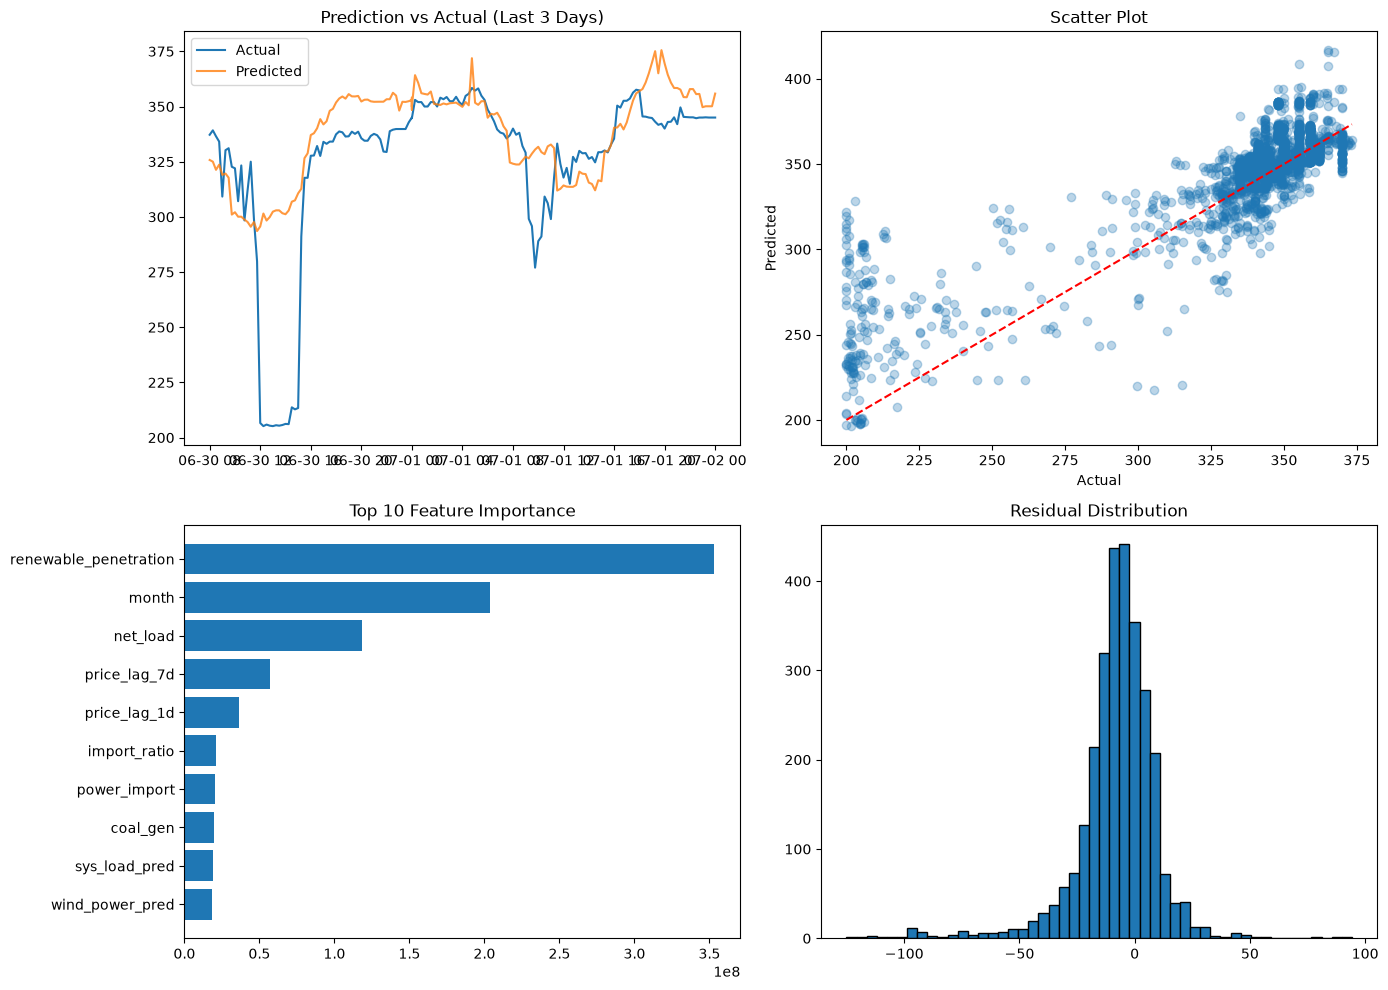

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 预测 vs 实际（最后3天）
sample = test.iloc[-3*POINTS_PER_DAY:].copy()
sample['pred'] = y_pred[-3*POINTS_PER_DAY:]
axes[0, 0].plot(sample['timestamp'], sample['target'], label='Actual')
axes[0, 0].plot(sample['timestamp'], sample['pred'], label='Predicted', alpha=0.8)
axes[0, 0].set_title('Prediction vs Actual (Last 3 Days)')
axes[0, 0].legend()

# 散点图
axes[0, 1].scatter(y_test, y_pred, alpha=0.3)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title('Scatter Plot')

# 特征重要性
imp = pd.DataFrame({'feature': feature_cols, 'importance': model.feature_importance(importance_type='gain')})
imp = imp.sort_values('importance', ascending=True).tail(10)
axes[1, 0].barh(imp['feature'], imp['importance'])
axes[1, 0].set_title('Top 10 Feature Importance')

# 残差
residual = y_test - y_pred
axes[1, 1].hist(residual, bins=50, edgecolor='k')
axes[1, 1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()